# Studio di un circuito RLC

Da un progetto di esame del 2022 svolto dallo studente **Giovanni Saturno**.

In questo elaborato si utilizzano le tecniche dell'analisi dei dati per lo studio di un circuito RLC, simulato con il software TINA.

L'intero dataset simulato è molto idealizzato.

In [12]:
from matplotlib import pyplot as plt
import pandas
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import math

I componenti del circuito sono:

In [13]:
R = 998          # Resitore di 0.998 kOhm
C = 330*10**-9   # Condensatore di 330 nF
L = 0.1          # Induttore da 100 mH
V = 1            # Generatore di ampiezza 1V

Si prelevano i dati e si raccolgono in un file excel, qui importato medianta apposita funzione della libreria pandas.
Le frequenze sono espresse in Hz, le tensioni in V e i tempi in s.

In [14]:
df = pandas.read_csv('data/dati-RLC.csv')
df.head()

,Frequency,V_R,Scala V,Delta t,Scala T
0,1.000000,0.0020,0.001,0.2480,0.040
1,3.019952,0.0062,0.001,0.0820,0.020
2,10.471285,0.0215,0.005,0.0236,0.004
3,20.892961,0.0430,0.010,0.0116,0.002
4,36.307805,0.0750,0.010,0.0066,0.002


I dati del data frame vengono utilizzati per calcolare le grandezze di interesse:
* $V_R$
* $\phi = 2 \pi \frac{\Delta t}{T}$

e le rispettive incertezze.

In [15]:
gain = df['V_R'].values
phase = 2*math.pi*df['Delta t'].values*df['Frequency'].values
freq = df['Frequency'].values
gain

array([0.002 , 0.0062, 0.0215, 0.043 , 0.075 , 0.17  , 0.225 , 0.26  ,
       0.295 , 0.335 , 0.38  , 0.44  , 0.49  , 0.56  , 0.62  , 0.7   ,
       0.77  , 0.84  , 0.9   , 0.94  , 0.98  , 1.    , 0.98  , 0.96  ,
       0.9   , 0.84  , 0.76  , 0.7   , 0.63  , 0.56  , 0.5   , 0.44  ,
       0.39  , 0.34  , 0.3   , 0.26  , 0.195 , 0.15  , 0.114 , 0.076 ,
       0.038 , 0.022 , 0.0144, 0.0032, 0.0016])

Supponendo uniforme la distribuzione di probabilità all'interno dell'intervallo di errore, degli errori andrebbero divisi per un fattore costante $2/\sqrt{12}=1/\sqrt{3}$, che in questo elaborato è omesso per semplicità, in quanto già sappiamo come si riflette sul risultato finale.

In [16]:
err_gain = (0.1*df['Scala V'].values)
err_phase = 2*0.1*math.pi*df['Scala T'].values*df['Frequency'].values

Si graficano poi l'ampiezza della tensione ai capi del resistore e la sua fase

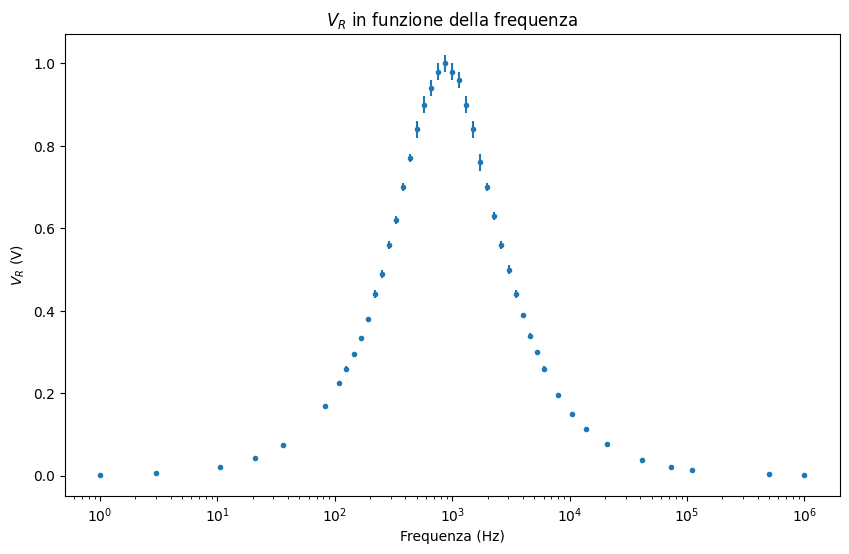

In [17]:
plt.figure(figsize=(10 ,6))
plt.errorbar(freq , gain, err_gain, ls='none', marker=".")
plt.xscale('log')
plt.title('$V_R$ in funzione della frequenza')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('$V_R$ (V)')
plt.show()

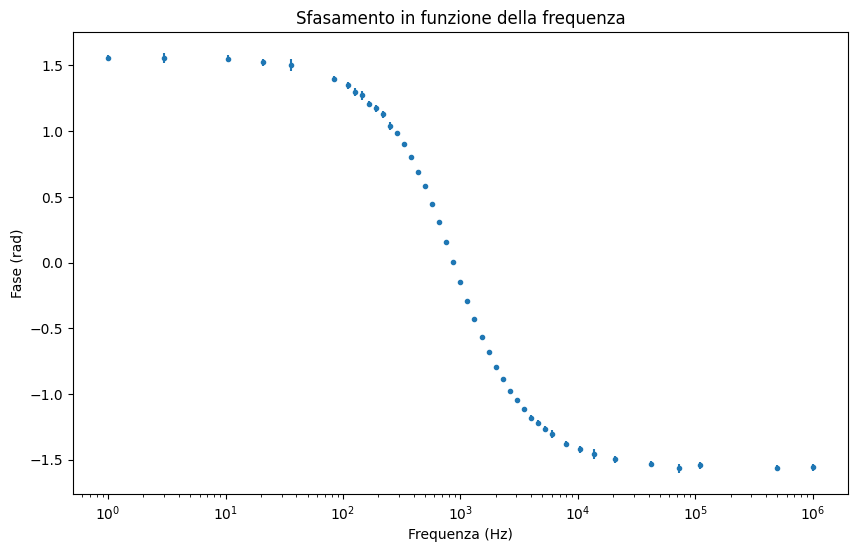

In [18]:
plt.figure(figsize=(10, 6))
plt.errorbar(freq , phase, err_phase, ls='none', marker=".")
plt.xscale('log')
plt.title('Sfasamento in funzione della frequenza')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Fase (rad)')
plt.show()

Dalla risoluzione teorica del circuito si ricava che la tensione ai capi del resistore è pari a:
$$ V_R = \frac{V_{gen}}{\sqrt{1+ Q^2 \left(\frac{f}{f_0} - \frac{f_0}{f}\right)^2}}$$

In [19]:
def model_gain(x, Q, f0):
    return V / np.sqrt(1 + (Q**2) * ((x/f0) - (f0/x))**2)

Si effettua, con l'ausilio della libreiria minuit, un fit:

In [20]:
least_squares_mode = LeastSquares(freq, gain, err_gain, model_gain)
m = Minuit(least_squares_mode, Q=0.5, f0=16000)
m.limits["Q"] = (0, 100000)
m.limits["f0"] = (0, 1000000)
m.migrad()
m.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.026 (χ²/ndof = 0.1)      │              Nfcn = 80               │
│ EDM = 7.33e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Q    │  0.5522   │  0.0019   │            │            │    0    │ 100000  │       │
│ 1 │ f0   │   876.2   │    2.7    │            │            │    0    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────┐
│    │        Q       f0 │
├────┼───────────────────┤
│  Q │ 3.52e-06 659.2e-6 │
│ f0 │ 659.2e-6     7.39 │
└────┴───────────────────┘

In [21]:
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.026 (χ²/ndof = 0.1)      │              Nfcn = 90               │
│ EDM = 3.38e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Q    │  0.5522   │  0.0019   │            │            │    0    │ 100000  │       │
│ 1 │ f0   │   876.2   │    2.7    │            │            │    0    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────┐
│    │        Q       f0 │
├────┼───────────────────┤
│  Q │ 3.52e-06 659.4e-6 │
│ f0 │ 659.4e-6     7.39 │
└────┴───────────────────┘

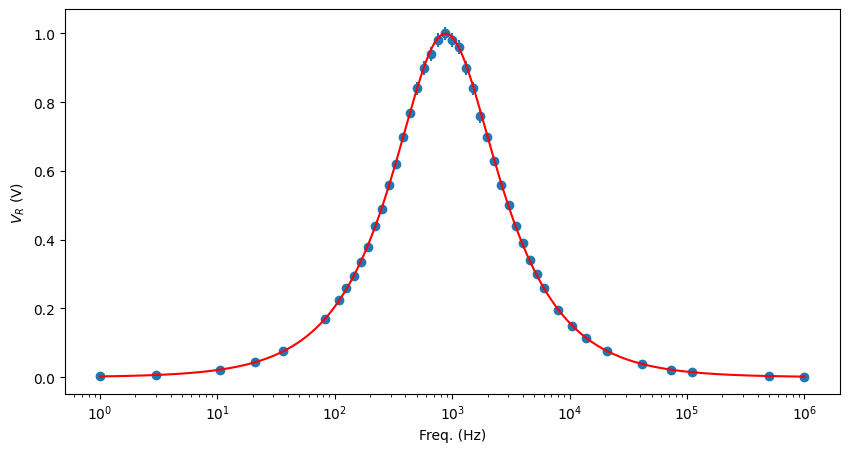

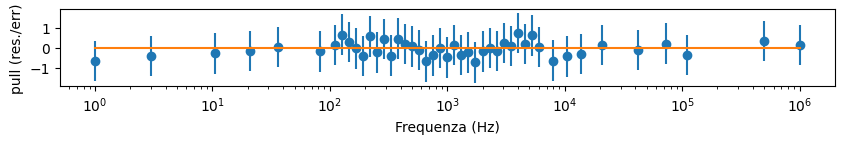

In [22]:
x=np.logspace(0, 6, num=200, base=10.0)
plt.figure(figsize=(10, 5))
plt.plot(x , model_gain(x, *m.values), color="red", zorder=2)
plt.errorbar(freq, gain, err_gain, ls='none', marker="o", zorder=1)
plt.xscale('log')
plt.xlabel('Freq. (Hz)')
plt.ylabel('$V_R$ (V)')
plt.show()
plt.figure(figsize=(10,1),dpi=100)
plt.errorbar(freq, (gain - model_gain(freq, *m.values))/err_gain, 1, fmt="o", zorder=1)
plt.plot([freq[0], freq[-1]], [0,0], zorder=2)
plt.xlabel('Frequenza (Hz)')
plt.ylabel('pull (res./err)')
plt.xscale('log')
plt.show()

Dal grafico dei *pull* (= residuo /errore) sembra che gli errori siano stati sovrastimati.

Si ricava quindi una stima della frequenza di risonanza e del fattore di merito.

In [23]:
print("Q = {:.4f} +/- {:.4f}".format(m.values["Q"], m.errors["Q"]))
print("f0 = {:.2f} +/- {:.1f} Hz".format(m.values["f0"], m.errors["f0"]))

Q = 0.5522 +/- 0.0019
f0 = 876.18 +/- 2.7 Hz


Si ripete poi lo stesso per la fase utilizzando il modello
$$\phi = -\arctan\left(Q \left(\frac{f}{f_0} - \frac{f_0}{f}\right)\right)$$

In [24]:
def model_phase(x, Q, f0):
    return -np.arctan(Q * ((x/f0) - (f0/x)))

In [25]:
least_squares_mode = LeastSquares(freq, phase, err_phase, model_phase)
m1 = Minuit(least_squares_mode, Q=0.5, f0=16000)
m1.limits["Q"] = (0, 3)
m1.limits["f0"] = (1, 1000000)
m1.migrad()
m1.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.896 (χ²/ndof = 0.1)      │              Nfcn = 149              │
│ EDM = 1.29e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Q    │  0.5518   │  0.0029   │            │            │    0    │    3    │       │
│ 1 │ f0   │   876.2   │    0.7    │            │            │    1    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────┐
│    │        Q       f0 │
├────┼───────────────────┤
│  Q │ 8.57e-06   234e-6 │
│ f0 │   234e-6    0.544 │
└────┴───────────────────┘

In [26]:
m1.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.896 (χ²/ndof = 0.1)      │              Nfcn = 162              │
│ EDM = 3.69e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Q    │  0.5518   │  0.0029   │            │            │    0    │    3    │       │
│ 1 │ f0   │   876.2   │    0.8    │            │            │    1    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────┐
│    │        Q       f0 │
├────┼───────────────────┤
│  Q │ 8.64e-06   165e-6 │
│ f0 │   165e-6    0.613 │
└────┴───────────────────┘

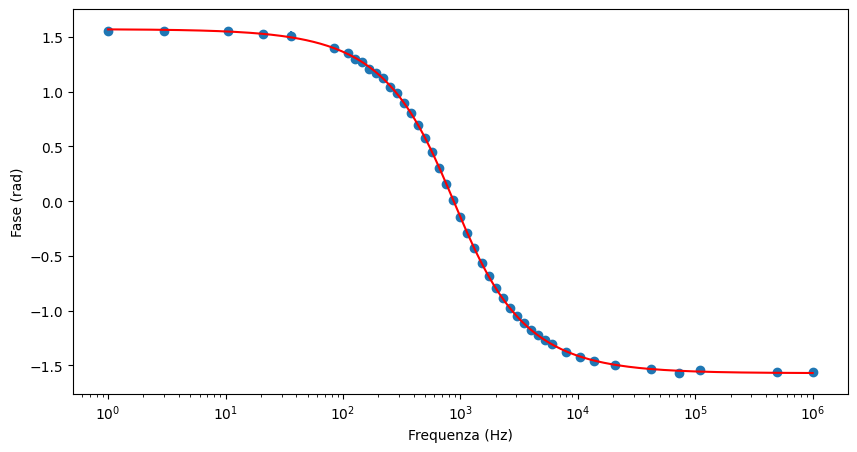

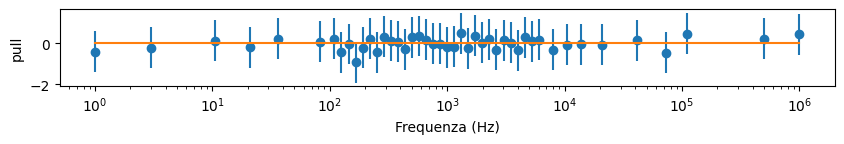

In [27]:
plt.figure(figsize=(10,5))
plt.errorbar(freq , phase, err_phase, ls="none", marker="o", zorder=1)
plt.plot(x , model_phase(x, *m1.values), color="red", zorder=2)
plt.xscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Fase (rad)')
plt.show()
plt.figure(figsize=(10,1),dpi=100)
plt.errorbar(freq, (phase - model_phase(freq, *m1.values))/err_phase, 1, fmt="o", zorder=1)
plt.plot([freq[0], freq[-1]], [0,0], zorder=2)
plt.xlabel('Frequenza (Hz)')
plt.ylabel('pull')
plt.xscale('log')
plt.show()

Dal fit ricaviamo che:

In [17]:
print("Q = {:.4f} +/- {:.4f}".format(m1.values["Q"], m1.errors["Q"]))
print("f0 = {:.2f} +/- {:.2f} Hz".format(m1.values["f0"], m1.errors["f0"]))

Q = 0.5518 +/- 0.0029
f0 = 876.18 +/- 0.78 Hz


Confrontiamo le stime dei parametri ottenuti dai due adattamenti:

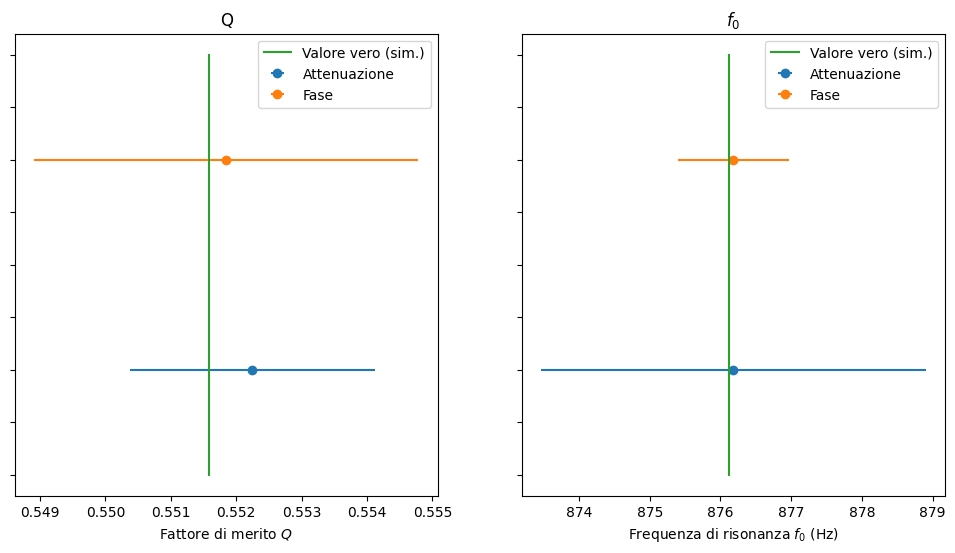

In [28]:
f0 = 1/((2*math.pi)*math.sqrt(L*C))
Q = 1/R*math.sqrt(L/C)

f  = plt.figure(figsize=(12,6))
a1 = plt.subplot(1,2,1)
a2 = plt.subplot(1,2,2)

a2.set_yticklabels(()),a1.set_yticklabels(())
a1.set_title("Q")
a2.set_title("$f_0$")
a1.errorbar(m.values[0] , 0, yerr=None, xerr=m.errors[0], ls="none", marker="o", zorder=1, label="Attenuazione")
a1.errorbar(m1.values[0] , 1, yerr=None, xerr=m1.errors[0], ls="none", marker="o", zorder=1, label="Fase")
a1.plot([Q,Q], [-0.5, 1.5], label="Valore vero (sim.)")
a1.set_xlabel('Fattore di merito $Q$')
a1.legend()
a2.errorbar(m.values[1] , 0, yerr=None, xerr=m.errors[1], ls="none", marker="o", zorder=1, label="Attenuazione")
a2.errorbar(m1.values[1] , 1, yerr=None, xerr=m1.errors[1], ls="none", marker="o", zorder=1, label="Fase")
a2.plot([f0, f0], [-0.5, 1.5], label="Valore vero (sim.)")
a2.set_xlabel('Frequenza di risonanza $f_0$ (Hz)')
a2.legend()
plt.show()


Notiamo che con un fit della fase si ottiene una stima più accurata della frequenza di risonanza, mentre con quella della tensione ai capi del resistore è privilegiato il fattore di merito.
Si prova poi con un fit simultaneo per stimare i due parametri di interesse:

In [29]:
ls_gain = LeastSquares(freq, gain, err_gain, model_gain)
ls_phase = LeastSquares(freq, phase, err_phase, model_phase)

chi_square_tot = ls_gain + ls_phase

mt = Minuit(chi_square_tot, Q=0.5, f0=16000)
mt.limits["Q"] = (0, 100000)
mt.limits["f0"] = (0, 1000000)

mt.migrad()
mt.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.936 (χ²/ndof = 0.1)      │              Nfcn = 93               │
│ EDM = 1.78e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Q    │  0.5521   │  0.0016   │            │            │    0    │ 100000  │       │
│ 1 │ f0   │   876.2   │    0.7    │            │            │    0    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────┐
│    │        Q       f0 │
├────┼───────────────────┤
│  Q │ 2.47e-06  94.6e-6 │
│ f0 │  94.6e-6    0.504 │
└────┴───────────────────┘

Si confronta il risultato ottenuto con i precedenti

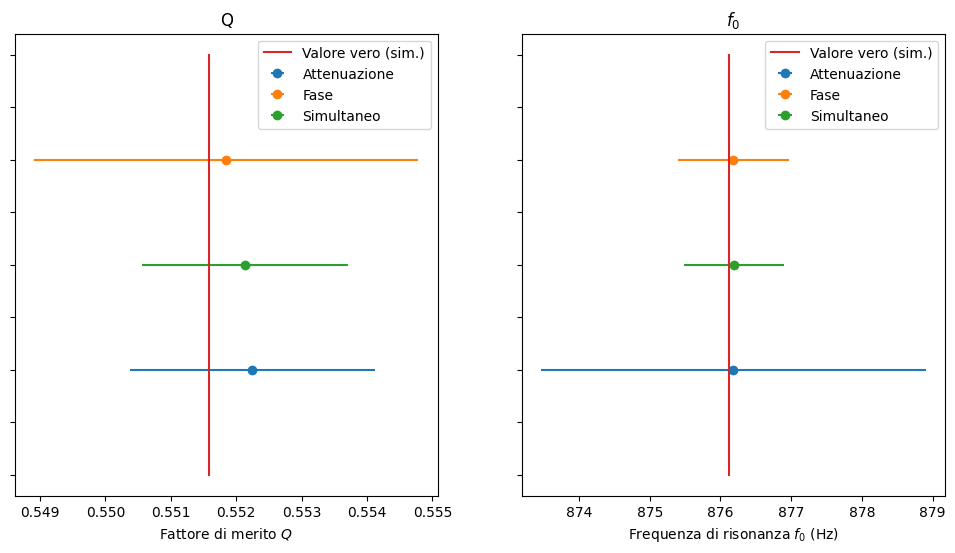

In [30]:
f  = plt.figure(figsize=(12,6))
a1 = plt.subplot(1,2,1)
a2 = plt.subplot(1,2,2)

a2.set_yticklabels(()),a1.set_yticklabels(())
a1.set_title("Q")
a2.set_title("$f_0$")
a1.errorbar(m.values[0] , 0, yerr=None, xerr=m.errors[0], ls="none", marker="o", zorder=1, label="Attenuazione")
a1.errorbar(m1.values[0] , 1, yerr=None, xerr=m1.errors[0], ls="none", marker="o", zorder=1, label="Fase")
a1.errorbar(mt.values[0] , 0.5, yerr=None, xerr=mt.errors[0], ls="none", marker="o", zorder=1, label="Simultaneo")
a1.plot([Q,Q], [-0.5, 1.5], label="Valore vero (sim.)")
a1.legend()
a1.set_xlabel('Fattore di merito $Q$')
a2.errorbar(m.values[1] , 0, yerr=None, xerr=m.errors[1], ls="none", marker="o", zorder=1, label="Attenuazione")
a2.errorbar(m1.values[1] , 1, yerr=None, xerr=m1.errors[1], ls="none", marker="o", zorder=1, label="Fase")
a2.errorbar(mt.values[1] , 0.5, yerr=None, xerr=mt.errors[1], ls="none", marker="o", zorder=1, label="Simultaneo")
a2.plot([f0, f0], [-0.5, 1.5], label="Valore vero (sim.)")
a2.set_xlabel('Frequenza di risonanza $f_0$ (Hz)')
a2.legend()
plt.show()

Come cambia la situazione considerando anche $V_{gen}$ come un parametro?

In [31]:
#Lasciamo libera la costante di normailzzazione
def model_ampl1(x, A, Q, f0):
    return A / np.sqrt(1 + (Q**2) * ((x/f0) - (f0/x))**2)

In [32]:
least_squares_mode = LeastSquares(freq, gain, err_gain, model_ampl1)
ia = Minuit(least_squares_mode, A=1, Q=0.5, f0=16000)
ia.limits["A"] = (0, 1)
ia.limits["Q"] = (0, 100000)
ia.limits["f0"] = (0, 1000000)
ia.migrad()
ia.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.758 (χ²/ndof = 0.1)      │              Nfcn = 306              │
│ EDM = 7.02e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.996   │   0.007   │            │            │    0    │    1    │       │
│ 1 │ Q    │   0.550   │   0.005   │            │            │    0    │ 100000  │       │
│ 2 │ f0   │   876.1   │    2.7    │            │            │    0    │  1e+06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────┐
│    │        A        Q       f0 │
├────┼────────────────────────────┤
│  A │ 4.82e-05 0.031e-3  1.42e-3 │
│  Q │ 0.031e-3 2.36e-05 1.575e-3 │
│ f0 │  1.42e-3 1.575e-3     7.45 │
└────┴────────────────────────────┘

In [33]:
def model_phase1(x, A, Q, f0):
    return model_phase(x, Q, f0)

ls_gain1 = LeastSquares(freq, gain, err_gain, model_ampl1)
ls_phase1 = LeastSquares(freq, phase, err_phase, model_phase1)

cost1 = ls_gain1 + ls_phase1

g1 = Minuit(cost1, A=0.996, Q=0.545, f0=800)
g1.limits["A"] = (0, 1.5)
g1.limits["Q"] = (0, 10)
g1.limits["f0"] = (1, 200000)

g1.migrad()
g1.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.769 (χ²/ndof = 0.1)      │              Nfcn = 92               │
│ EDM = 2.59e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.998   │   0.004   │            │            │    0    │   1.5   │       │
│ 1 │ Q    │  0.5513   │  0.0025   │            │            │    0    │   10    │       │
│ 2 │ f0   │   876.2   │    0.7    │            │            │    1    │ 200000  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────┐
│    │        A        Q       f0 │
├────┼────────────────────────────┤
│  A │ 1.81e-05     8e-6 0.204e-3 │
│  Q │     8e-6 6.27e-06   188e-6 │
│ f0 │ 0.204e-3   188e-6    0.507 │
└────┴────────────────────────────┘

I risultati ottenuti sono confrontati con i precedenti

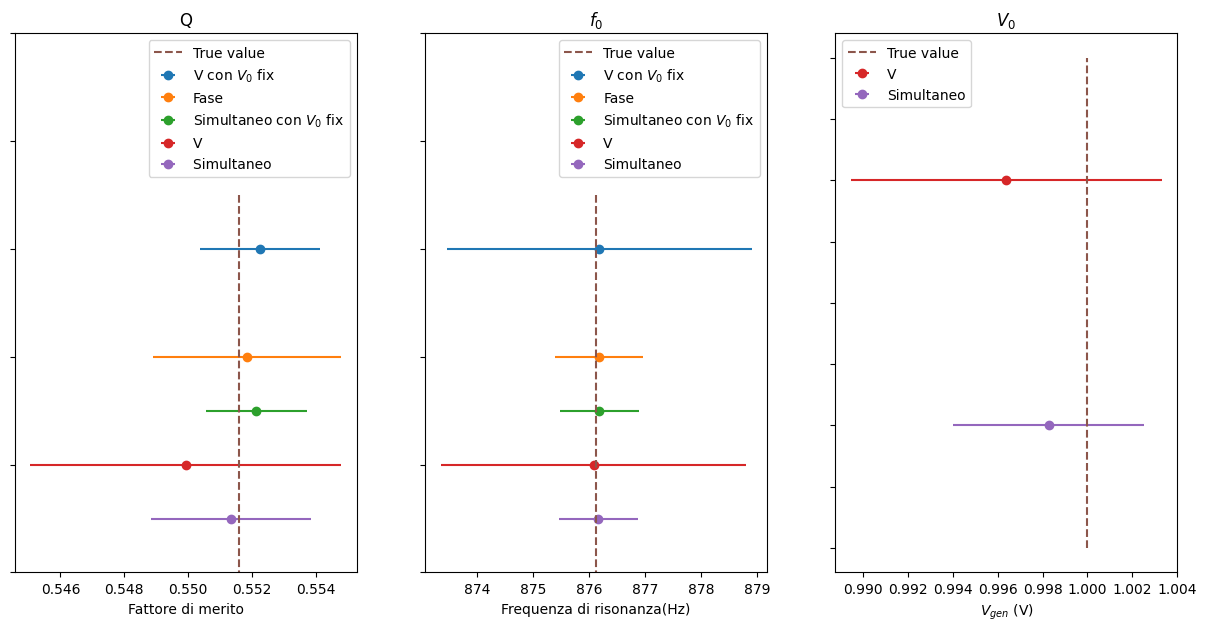

In [34]:
f  = plt.figure(figsize=(15,7))
a1 = plt.subplot(1,3,1)
a2 = plt.subplot(1,3,2)
a3 = plt.subplot(1,3,3)
f0 = 1/((2*math.pi)*math.sqrt(L*C))
Q = 1/R*math.sqrt(L/C)

a3.set_yticklabels(()),a2.set_yticklabels(()),a1.set_yticklabels(())
a2.set_ylim(3, -2), a1.set_ylim(3, -2)
a1.set_title("Q")
a2.set_title("$f_0$")
a1.errorbar(m.values[0] , 0, yerr=None, xerr=m.errors[0], ls="none", marker="o", zorder=1, label="V con $V_0$ fix")
a1.errorbar(m1.values[0] , 1, yerr=None, xerr=m1.errors[0], ls="none", marker="o", zorder=1, label="Fase")
a1.errorbar(mt.values[0] , 1.5, yerr=None, xerr=mt.errors[0], ls="none", marker="o", zorder=1, label="Simultaneo con $V_0$ fix")
a1.errorbar(ia.values[1] , 2, yerr=None, xerr=ia.errors[1], ls="none", marker="o", zorder=1, label="V ")
a1.errorbar(g1.values[1] , 2.5, yerr=None, xerr=g1.errors[1], ls="none", marker="o", zorder=1, label="Simultaneo ")
a1.plot([Q,Q], [-0.5, 4], linestyle='--', label='True value')
a1.legend()
a2.errorbar(m.values[1] , 0, yerr=None, xerr=m.errors[1], ls="none", marker="o", zorder=1, label="V con $V_0$ fix")
a2.errorbar(m1.values[1] , 1, yerr=None, xerr=m1.errors[1], ls="none", marker="o", zorder=1, label="Fase")
a2.errorbar(mt.values[1] , 1.5, yerr=None, xerr=mt.errors[1], ls="none", marker="o", zorder=1, label="Simultaneo con $V_0$ fix")
a2.errorbar(ia.values[2] , 2, yerr=None, xerr=ia.errors[2], ls="none", marker="o", zorder=1, label="V")
a2.errorbar(g1.values[2] , 2.5, yerr=None, xerr=g1.errors[2], ls="none", marker="o", zorder=1, label="Simultaneo")
a2.plot([f0, f0], [-0.5, 3], linestyle='--', label='True value')
a3.errorbar(ia.values[0] , 1, yerr=None, xerr=ia.errors[0], ls="none", marker="o", zorder=1, label="V", color='#d62728')
a3.errorbar(g1.values[0] , 0, yerr=None, xerr=g1.errors[0], ls="none", marker="o", zorder=1, label="Simultaneo", color='#9467bd')
a3.set_title("$V_0$")
a3.plot([1,1], [-0.5, 1.5], linestyle='--', label='True value', color='#8c564b')
a2.legend()
a3.legend()
a1.set_xlabel('Fattore di merito')
a2.set_xlabel('Frequenza di risonanza(Hz)')
a3.set_xlabel('$V_{gen}$ (V)')
plt.show()